# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import sys
#!{sys.executable} -m pip install scikit-survival
#!conda install -c conda-forge scikit-survival -y
#pip install scikit-survival

In [3]:
# Configurações de estilo para os gráficos da apresentação
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<a class="anchor" id="1.1 Import Libraries">

## 1.2 Data Loading
    
</a>

In [4]:
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\BNP-Paribas-main\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Ler o ficheiro parquet
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

# Carregar o dataset pré-processado
df = pd.read_csv(file_path_BNP_teste)

In [5]:
BNP_teste[BNP_teste['CHURN'] == True]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,...,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,...,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,1,0,2019-01-28,2024-01-31,2024-01-31,72,34,34,...,Unknown,1,1.0,0.0,0.000000,3,S,A,69,0.000000
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,0,1,2007-06-29,2024-03-31,2024-03-31,84,24,24,...,Unknown,1,1.0,0.0,0.000000,7,V,P,74,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,1,0,2021-10-26,2024-10-31,2024-10-31,84,36,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,0,1,2022-09-27,2024-09-30,2024-09-30,24,24,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,...,Unknown,1,1.0,0.0,0.000000,4,S,P,33,0.200000
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,...,Unknown,1,1.0,156.0,0.064103,17,X,F,33,0.055556


<a class="anchor" id="1.1 Import Libraries">

## 2. Target Engineering
    
</a>

In [6]:
# 1. Target para Classificação (Binário)
df['TARGET'] = df['CHURN'].fillna(0).astype(int)

# 2. Targets para Sobrevivência (Event e Duration)
df['event'] = df['TARGET']
# Garantimos que a duração é no mínimo 1 dia para o Cox não crashar
df['duration'] = df['DOSSIER_DURATION_DAYS'].clip(lower=1).fillna(1)
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'])

In [7]:
features_for_survival = [
    'DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC',
    'RESSO_mean', 'NBENF_mean',
    'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
    'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean',
    'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
    'sdem_age', 'active_credit_ratio', 'POLE', 'PRODALP', 'PAGAMENTO', 
    'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO',
    'AGFIN', 'PTT'
]

<a class="anchor" id="1.1 Import Libraries">

## 3. Time-Based Split
    
</a>

In [8]:
train_df = df[df['CLOSE_DATE'].notna()].copy()
test_df = df[df['CLOSE_DATE'].isna()].copy()

In [9]:
train_data, val_data = train_test_split(train_df,
                                        test_size = 0.2,
                                        random_state = 42,
                                        stratify=train_df['event'])

In [10]:
# Criamos os X selecionando as colunas da tua lista
X_train = train_df[features_for_survival].copy()
X_val = val_data[features_for_survival].copy()
X_test = test_df[features_for_survival].copy()

# Criamos os y
y_train = train_df['TARGET']
y_val = val_data['TARGET']

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)

Shape X_train: (76646, 28)
Shape X_val: (15330, 28)


## Encoding

In [11]:
# 1. Identificar as colunas de texto apenas dentro do nosso X_train já filtrado
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    # 2. Calcular a frequência no Treino
    freq_map = X_train[col].value_counts(normalize=True)
    
    # 3. Criar a nova variável com o sufixo _encoded (como o João fez)
    X_train[f"{col}_encoded"] = X_train[col].map(freq_map)
    X_val[f"{col}_encoded"] = X_val[col].map(freq_map).fillna(0)
    X_test[f"{col}_encoded"] = X_test[col].map(freq_map).fillna(0)
    
    # 4. Apagar a coluna original (texto) para não confundir o modelo
    X_train = X_train.drop(columns=[col])
    X_val = X_val.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

print(f"Encoding concluído. Foram criadas as versões '_encoded' para: {list(cat_cols)}")
print(f"Colunas no X_train: {X_train.columns.tolist()}")

Encoding concluído. Foram criadas as versões '_encoded' para: ['POLE', 'PRODALP', 'PAGAMENTO', 'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO']
Colunas no X_train: ['DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC', 'RESSO_mean', 'NBENF_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean', 'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky', 'sdem_age', 'active_credit_ratio', 'AGFIN', 'PTT', 'POLE_encoded', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'sdem_SITFAM_encoded', 'sdem_HABITAT_encoded', 'kp_sqe_encoded', 'NATIO_encoded']


In [12]:
X_train.head()

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,...,AGFIN,PTT,POLE_encoded,PRODALP_encoded,PAGAMENTO_encoded,MODCONTACTO_encoded,sdem_SITFAM_encoded,sdem_HABITAT_encoded,kp_sqe_encoded,NATIO_encoded
0,84,158.359889,0.0,8000.00,0.0,1395.9935,0.0,0,-1.0,0.36,...,118.0,8600,0.985753,0.752472,0.969835,0.603998,0.197375,0.275696,0.02839,0.990828
1,120,280.401466,0.0,16000.00,0.0,1513.4660,0.0,1,0.0,0.36,...,118.0,8600,0.985753,0.752472,0.969835,0.603998,0.197375,0.275696,0.02839,0.990828
3,60,424.699203,0.0,13467.54,0.0,678.4830,2.0,0,-1.0,1.32,...,117.0,2745,0.985753,0.752472,0.969835,0.014691,0.400725,0.358584,0.71307,0.990828
4,60,184.214593,0.0,5985.57,0.0,678.4830,2.0,1,1.0,1.32,...,117.0,2745,0.985753,0.752472,0.969835,0.014691,0.400725,0.358584,0.71307,0.990828
5,72,56.017772,0.0,2500.00,0.0,838.1860,0.0,0,-1.0,1.32,...,120.0,2855,0.985753,0.752472,0.030152,0.377515,0.197375,0.358584,0.71307,0.990828


In [13]:
# Identificar colunas que são datas
#date_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remover essas colunas
#X_train = X_train.drop(columns=date_cols)
#X_val = X_val.drop(columns=date_cols)
#X_test = X_test.drop(columns=date_cols)

#print(f"Colunas de data removidas: {list(date_cols)}")

# 3. Agora a variância corre sem problemas
#variances = X_train.var()
#low_variance_cols = variances[variances < 0.01].index
# ... continuar o drop das low_variance_cols

<a class="anchor" id="1.1 Import Libraries">

## 4. Feature Selection
    
</a>

### 4.1 Filter Methods

#### Variance

In [14]:
variances = X_train.var()

# Identificar colunas com quase nenhuma variação (threshold 0.01)
low_variance_cols = variances[variances < 0.01].index

print(low_variance_cols)

Index(['CRD_min', 'sdem_HABITAT_encoded', 'NATIO_encoded'], dtype='object')


#### Correlation Matrix

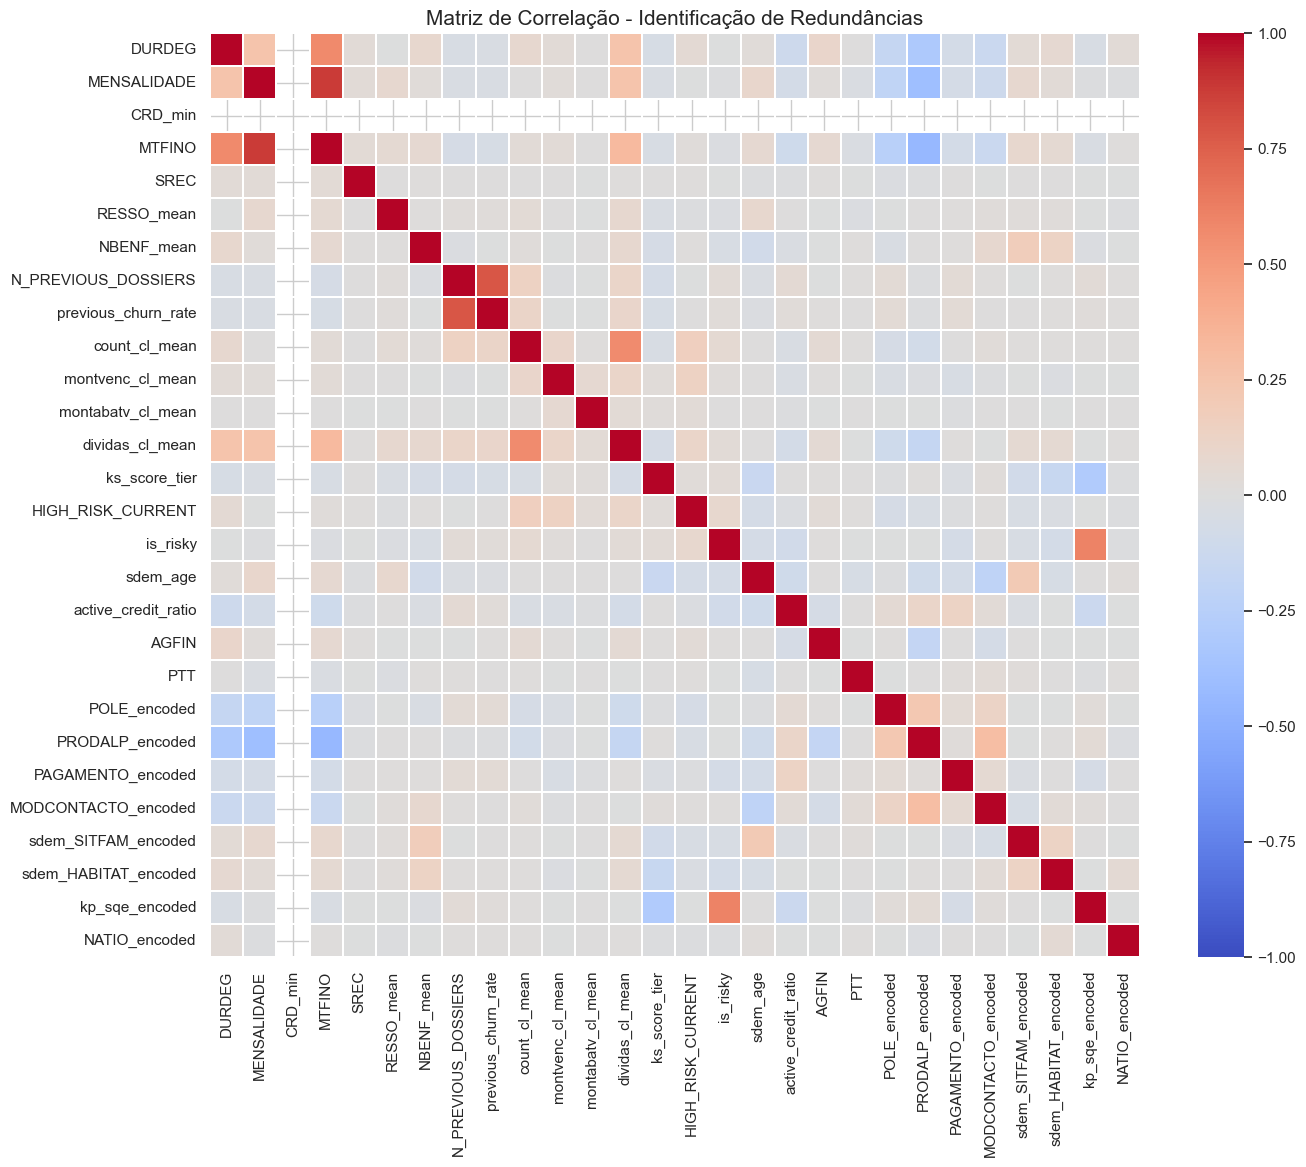

In [15]:
# 1. Calcular a matriz de correlação
corr_matrix = X_train.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(15, 12))
# Usamos um mapa de cores divergente (coolwarm) para distinguir correlações positivas e negativas
sns.heatmap(corr_matrix, 
            annot=False, # Definimos como False porque com muitas colunas os números não se leem
            cmap='coolwarm', 
            vmin=-1, vmax=1, # Escala fixa de -1 a 1
            linewidths=0.1)

plt.title("Matriz de Correlação - Identificação de Redundâncias", fontsize=15)
plt.show()

#### Mutual Information

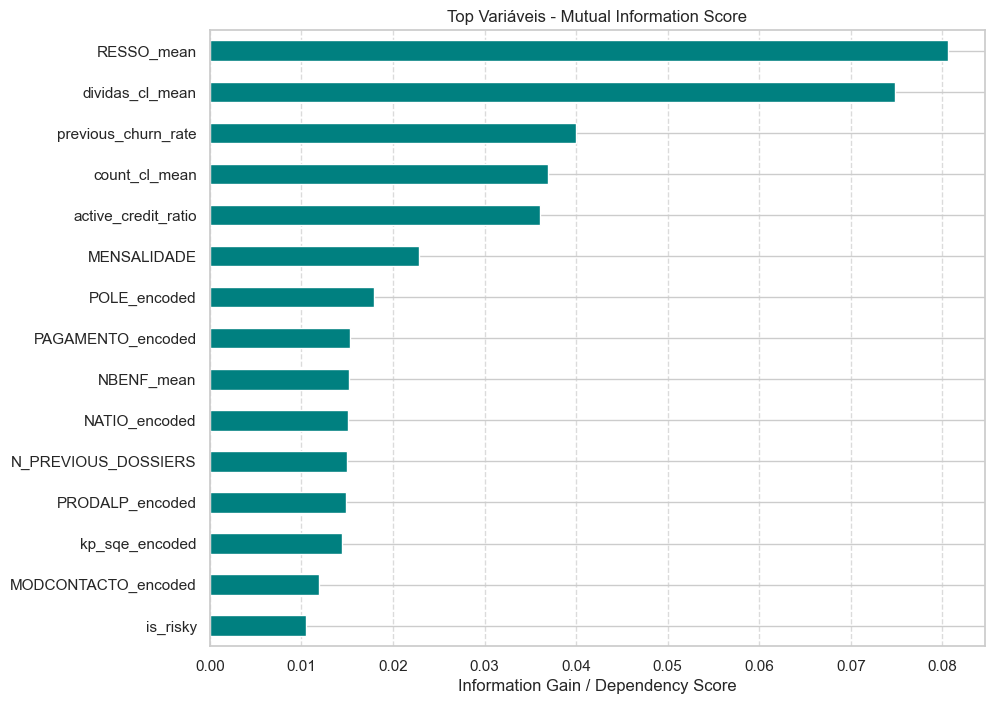

In [16]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 2. Organizar os resultados num Pandas Series
mi_importance = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mi_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Top Variáveis - Mutual Information Score")
plt.xlabel("Information Gain / Dependency Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

mi_selected_features = mi_importance.head(25).index.tolist()

## Wrapper Methods

In [17]:
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

# 2. Configurar o RFE
selector = RFE(estimator=rf, n_features_to_select=15, step=1, verbose=1)

In [18]:
print("A treinar o modelo de seleção (RFE)...")
selector.fit(X_train, y_train)

# 4. Extrair os resultados
selected_features = X_train.columns[selector.get_support()].tolist()
ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': selector.ranking_}).sort_values('Ranking')

print(f"\nO modelo escolheu estas 15 variáveis: \n{selected_features}")

A treinar o modelo de seleção (RFE)...
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.

O modelo escolheu estas 15 variáveis: 
['DURDEG', 'MTFINO', 'RESSO_mean', 'NBENF_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'montvenc_cl_mean', 'dividas_cl_mean', 'active_credit_ratio', 'AGFIN', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'kp_sqe_encoded']


### Embedded methods

#### Random Forest

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76646 entries, 0 to 185599
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DURDEG                76646 non-null  int64  
 1   MENSALIDADE           76646 non-null  float64
 2   CRD_min               76646 non-null  float64
 3   MTFINO                76646 non-null  float64
 4   SREC                  76646 non-null  float64
 5   RESSO_mean            76646 non-null  float64
 6   NBENF_mean            76646 non-null  float64
 7   N_PREVIOUS_DOSSIERS   76646 non-null  int64  
 8   previous_churn_rate   76646 non-null  float64
 9   count_cl_mean         76646 non-null  float64
 10  montvenc_cl_mean      76646 non-null  float64
 11  montabatv_cl_mean     76646 non-null  float64
 12  dividas_cl_mean       76646 non-null  float64
 13  ks_score_tier         76646 non-null  int64  
 14  HIGH_RISK_CURRENT     76646 non-null  float64
 15  is_risky              7


Relatório de Classificação (Validation Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2374
           1       1.00      1.00      1.00     12956

    accuracy                           1.00     15330
   macro avg       1.00      1.00      1.00     15330
weighted avg       1.00      1.00      1.00     15330

ROC-AUC Score: 1.0000


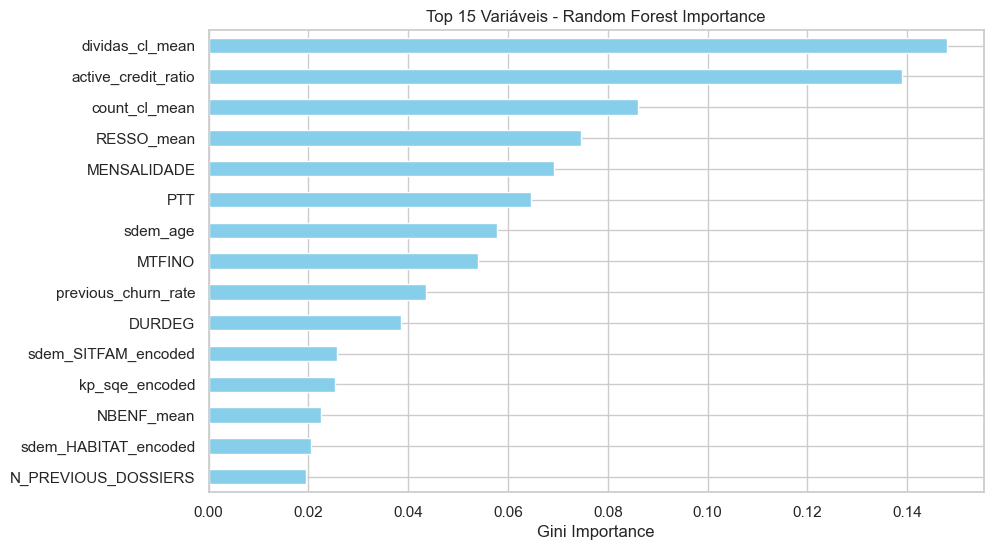

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)

# 2. Treinar o modelo
rf_model.fit(X_train, y_train)

# 3. Fazer as Previsões de Validação (O "Certificado de Qualidade" do João)
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# 4. Mostrar as Métricas (Benchmarking antecipado)
print("\nRelatório de Classificação (Validation Set):")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_prob):.4f}")

# 5. Extrair e Visualizar a Importância das Variáveis (A Seleção propriamente dita)
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variáveis - Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

# Guardar a lista das top 15 para o consenso final
rf_selected_features = rf_importance.head(15).index.tolist()

#### XGBOOST

In [21]:
#pip install xgboost

Negative class count: 11871
Positive class count: 64775
scale_pos_weight: 0.1832651485912775
A treinar XGBoost com scale_pos_weight: 0.18...
              precision    recall  f1-score   support

           0       0.33      0.88      0.48      2374
           1       0.97      0.67      0.79     12956

    accuracy                           0.70     15330
   macro avg       0.65      0.77      0.63     15330
weighted avg       0.87      0.70      0.74     15330

 Validation ROC-AUC:: 0.8550


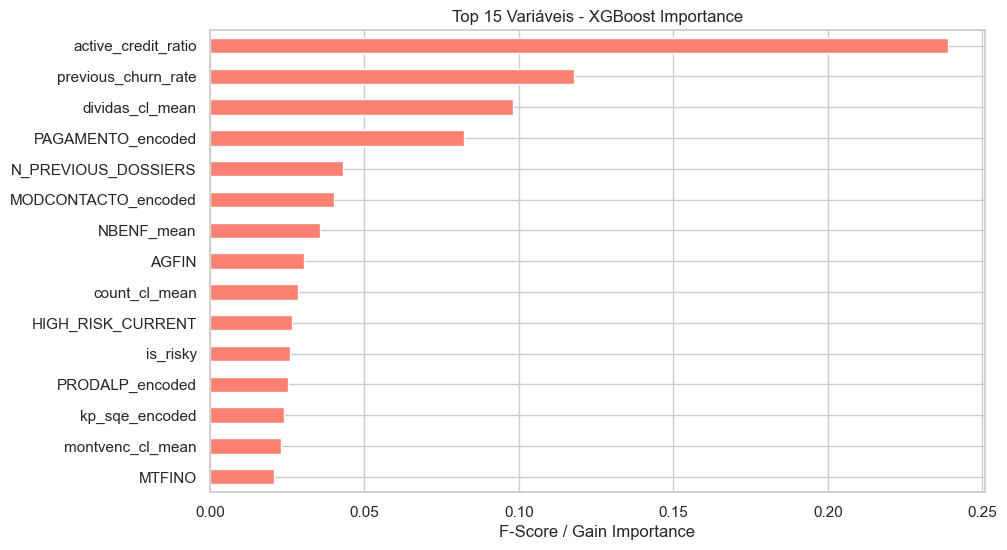

In [22]:
# 2. Calcular o weights
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", scale_pos_weight)

# 3. Configurar o Modelo 
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,                # Árvores menos profundas para evitar overfitting
    learning_rate=0.05,         # Passo mais lento para maior precisão
    subsample=0.8,              # Usa 80% dos dados em cada árvore
    colsample_bytree=0.8,       # Usa 80% das colunas em cada árvore
    scale_pos_weight=scale_pos_weight, 
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 4. Treinar o modelo
print(f"A treinar XGBoost com scale_pos_weight: {scale_pos_weight:.2f}...")
xgb_model.fit(X_train, y_train)

# 5. Previsões e Avaliação (O "Selo de Garantia")
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_xgb))
print(f" Validation ROC-AUC:: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")


# 6. Visualização das Top 15 Variáveis
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 15 Variáveis - XGBoost Importance")
plt.xlabel("F-Score / Gain Importance")
plt.show()

xgb_selected_features = xgb_importance.head(15).index.tolist()

## Random Survival Forest

In [24]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.inspection import permutation_importance

# =========================================================
# 1) X datasets: full numeric + categorical encoded
# =========================================================

X_train_rsf = X_train.copy()
X_val_rsf = X_val.copy()

# =========================================================
# 2) y datasets no formato survival
# =========================================================

y_train_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=train_df
)

y_val_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=val_data
)

# =========================================================
# 3) Random Survival Forest model
# =========================================================

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=20,
    min_samples_leaf=30,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train_rsf, y_train_rsf)

# =========================================================
# 4) Performance
# =========================================================

train_cindex = rsf.score(X_train_rsf, y_train_rsf)
val_cindex = rsf.score(X_val_rsf, y_val_rsf)

print("Train C-index:", train_cindex)
print("Validation C-index:", val_cindex)

# =========================================================
# 5) Permutation importance
# =========================================================
# Nota:
# usamos validation set para medir a importância de forma mais robusta

perm_result = permutation_importance(
    rsf,
    X_val_rsf,
    y_val_rsf,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

rsf_importance = pd.Series(
    perm_result.importances_mean,
    index=X_val_rsf.columns
).sort_values(ascending=False)

print("\nTop 25 RSF full feature importances:")
print(rsf_importance.head(25))

# opcional: também guardar std da importance
rsf_importance_df = pd.DataFrame({
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}, index=X_val_rsf.columns).sort_values("importance_mean", ascending=False)

print("\nTop 25 RSF full feature importances with std:")
print(rsf_importance_df.head(25))

MemoryError: could not allocate 181600256 bytes

In [ ]:
# 5. Extrair e Visualizar a Importância das Variáveis (A Seleção propriamente dita)
rsf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rsf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variáveis - Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

### Final Insights

| Predictor | Variance | Spearman Corr | Mutual Info | Wrapper (SFFS) | RF Importance | XGB Importance | Random Survival Forest | **Decision** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- | :--- |
| **CRD_min** | Discard | Discard | Keep | Keep | Keep | Keep | :--- | **Include** |
| **active_credit_ratio** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **previous_churn_rate** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **MTFINO** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **DURDEG** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **RESSO_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **dividas_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **N_PREVIOUS_DOSSIERS** | Keep | Discard | Keep | Keep | Keep | Keep | :--- | **Discard** |
| **count_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **montvenc_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **MENSALIDADE** | Keep | Discard | Keep | Keep | Keep | Keep | :--- | **Try w/o (Collinear)** |
| **AGFIN_encoded** | Keep | Keep | Keep | Keep | Keep | Discard | :--- | **Include** |
| **POLE_encoded** | Keep | Keep | Keep | Discard | Keep | Keep | :--- | **Include** |
| **SREC** | Keep | Keep | Keep | Discard | Keep | Keep | :--- | **Include** |
| **PRODALP_encoded** | Keep | Keep | Discard | Keep | Keep | Keep | :--- | **Include** |
| **PAGAMENTO_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **MODCONTACTO_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **kp_sqe_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **NATIO_encoded** | Keep | Keep | Discard | Discard | Discard | Keep | :--- | **Discard** |
| **is_risky** | Keep | Keep | Discard | Discard | Discard | Keep | :--- | **Discard** |

* Spearman Corr: A variável `MENSALIDADE` apresenta uma correlação superior a 0.90 com o `MTFINO` (Montante), tirar de uma delas.
* Wrapper (SFFS): Inclui as variáveis selecionadas pelo algoritmo sequencial que otimizou a performance do modelo.
* Mutual Info: Identifica dependências não-lineares; variáveis como `NATIO_encoded` e `is_risky` foram penalizadas por este método.

In [ ]:
['DURDEG', 'MENSALIDADE', 'MTFINO', 'RESSO_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 
 'count_cl_mean', 'montvenc_cl_mean', 'dividas_cl_mean', 'active_credit_ratio', 'AGFIN', 'PRODALP_encoded', 
 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'kp_sqe_encoded']


['DURDEG',
 'MENSALIDADE',
 'MTFINO',
 'RESSO_mean',
 'N_PREVIOUS_DOSSIERS',
 'previous_churn_rate',
 'count_cl_mean',
 'montvenc_cl_mean',
 'dividas_cl_mean',
 'active_credit_ratio',
 'AGFIN',
 'PRODALP_encoded',
 'PAGAMENTO_encoded',
 'MODCONTACTO_encoded',
 'kp_sqe_encoded']

## Model

In [ ]:
train_survival_full = pd.concat([X_train, train_data[['duration','event']]],axis=1)

val_survival_full = pd.concat([X_val_full, val_data[['duration','event']]],axis=1)